In [6]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END

In [7]:
class AgentState(TypedDict):
    num1: int
    num2: int
    num3: int
    num4: int
    operation1: str
    operation2: str
    first_result: int
    second_result: int

In [ ]:
def adder(state: AgentState) -> AgentState:
    """This nodes add a numbers"""
    state["result"] = state["num1"] + state["num2"]

    return state


def subtractor(state: AgentState) -> AgentState:
    state["result"] = state["num1"] - state["num2"]

    return state


def decide_next_node(state: AgentState) -> AgentState:
    if state["operation1"] == "+":
        return "addition_operation"

    elif state["operation1"] == "-":
        return "subtraction_operation"

def decide_next_node_2(state: AgentState) -> AgentState:
    if state["operation1"] == "+":
        return "addition_operation"

    elif state["operation1"] == "-":
        return "subtraction_operation"

In [ ]:
graph = StateGraph(AgentState)

# Stage 1
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router1", lambda state: state)

graph.add_edge(START, "router1")
graph.add_conditional_edges(
    "router1",
    decide_next_node,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

# Connect Stage 1 to Stage 2 
graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")

#  Stage 2
graph.add_node("add_node_2", adder)
graph.add_node("subtract_node_2", subtractor)
graph.add_node("router2", lambda state: state)

graph.add_conditional_edges(
    "router2",
    decide_next_node_2,
    {
        "addition_operation": "add_node_2",
        "subtraction_operation": "subtract_node_2" 
    }
)

graph.add_edge("add_node_2", END)
graph.add_edge("subtract_node_2", END)

app = graph.compile()

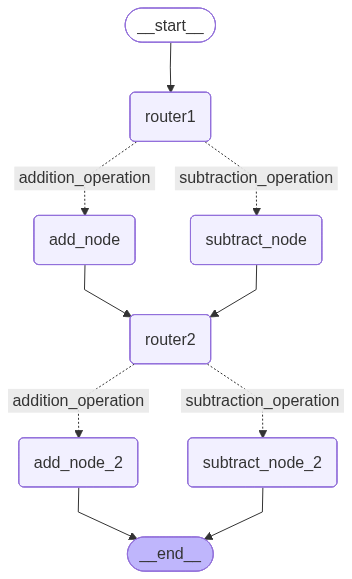

In [13]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))